In [1]:
import requests
import pandas as pd

url = "https://apidatos.ree.es/es/datos/demanda/evolucion"

params = {
    "start_date": "2024-01-01T00:00",
    "end_date": "2024-01-31T23:59",
    "time_trunc": "day"
}

response = requests.get(url, params=params)

print(response.status_code)
print(response.text[:500])

200
{"data":{"type":"Evoluci\u00f3n de la demanda","id":"dem1","attributes":{"title":"Evoluci\u00f3n de la demanda","last-update":"2025-01-28T16:56:22.000+01:00","description":null},"meta":{"cache-control":{"cache":"HIT","expireAt":"2026-06-12T09:55:06"}}},"included":[{"type":"Demanda","id":"10297","groupId":null,"attributes":{"title":"Demanda","description":null,"color":"#ffea00","icon":null,"type":null,"magnitude":null,"composite":false,"last-update":"2025-01-28T16:56:22.000+01:00","values":[{"val


In [2]:
response.json().keys()
data = response.json()
data 

{'data': {'type': 'Evolución de la demanda',
  'id': 'dem1',
  'attributes': {'title': 'Evolución de la demanda',
   'last-update': '2025-01-28T16:56:22.000+01:00',
   'description': None},
  'meta': {'cache-control': {'cache': 'HIT',
    'expireAt': '2026-06-12T09:55:06'}}},
 'included': [{'type': 'Demanda',
   'id': '10297',
   'groupId': None,
   'attributes': {'title': 'Demanda',
    'description': None,
    'color': '#ffea00',
    'icon': None,
    'type': None,
    'magnitude': None,
    'composite': False,
    'last-update': '2025-01-28T16:56:22.000+01:00',
    'values': [{'value': 555244.867,
      'percentage': 1,
      'datetime': '2024-01-01T00:00:00.000+01:00'},
     {'value': 703015.288,
      'percentage': 1,
      'datetime': '2024-01-02T00:00:00.000+01:00'},
     {'value': 721647.165,
      'percentage': 1,
      'datetime': '2024-01-03T00:00:00.000+01:00'},
     {'value': 726021.564,
      'percentage': 1,
      'datetime': '2024-01-04T00:00:00.000+01:00'},
     {'valu

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil.relativedelta import relativedelta

end_date = datetime.today()
start_date = end_date - relativedelta(years=10)

url = "https://apidatos.ree.es/es/datos/demanda/evolucion"

params = {
    "start_date": start_date.strftime("%Y-%m-%dT%H:%M"),
    "end_date": end_date.strftime("%Y-%m-%dT%H:%M"),
    "time_trunc": "day"
}

response = requests.get(url, params=params)

print(response.status_code)
print(response.text[:300])
data = response.json()

values = data["included"][0]["attributes"]["values"]

df_demanda = pd.DataFrame(values)

df_demanda["datetime"] = pd.to_datetime(df_demanda["datetime"], utc=True)
df_demanda["datetime_spain"] = df_demanda["datetime"].dt.tz_convert("Europe/Madrid")

df_demanda.head()

400
{"errors":[{"status":"400","title":"Error Interno","detail":"Los datos solicitados no est\u00e1n disponibles en este momento. Int\u00e9ntelo de nuevo m\u00e1s tarde."}]}


KeyError: 'included'

In [3]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil.relativedelta import relativedelta
import time 

url = "https://apidatos.ree.es/es/datos/demanda/evolucion"

end_date = datetime.today()

all_values = []

for year in range(2016, 2026):
    start = f"{year}-01-01T00:00"
    end = f"{year}-12-31T23:59"
    
    params = {
        "start_date": start,
        "end_date": end,
        "time_trunc": "day"
    }
    
    print(f"Descargando datos para {year}...")
    
    response = requests.get(url, params=params)
    
    print("Status:", response.status_code)
    
    if response.status_code == 200:
        
        data = response.json()
        if "included" in data:
            values = data["included"][0]["attributes"]["values"]
            all_values.extend(values)
            print(f"{len(values)} registros")
        else:
            print("No tiene 'included'")
            print(data)
    else:
        print(response.text[:500])
    time.sleep(1)

        


Descargando datos para 2016...
Status: 200
366 registros
Descargando datos para 2017...
Status: 200
365 registros
Descargando datos para 2018...
Status: 200
365 registros
Descargando datos para 2019...
Status: 200
365 registros
Descargando datos para 2020...
Status: 200
366 registros
Descargando datos para 2021...
Status: 200
365 registros
Descargando datos para 2022...
Status: 200
365 registros
Descargando datos para 2023...
Status: 200
365 registros
Descargando datos para 2024...
Status: 200
366 registros
Descargando datos para 2025...
Status: 200
365 registros


In [4]:
df_demanda = pd.DataFrame(all_values)

df_demanda["datetime"] = pd.to_datetime(
    df_demanda["datetime"],
    utc = True
)

df_demanda["datetime_spain"] = (
    df_demanda["datetime"]
    .dt.tz_convert("Europe/Madrid")
)

df_demanda.head()

,value,percentage,datetime,datetime_spain
0,549334.251,1,2015-12-31 23:00:00+00:00,2016-01-01 00:00:00+01:00
1,614370.924,1,2016-01-01 23:00:00+00:00,2016-01-02 00:00:00+01:00
2,619728.026,1,2016-01-02 23:00:00+00:00,2016-01-03 00:00:00+01:00
3,704966.605,1,2016-01-03 23:00:00+00:00,2016-01-04 00:00:00+01:00
4,701386.909,1,2016-01-04 23:00:00+00:00,2016-01-05 00:00:00+01:00


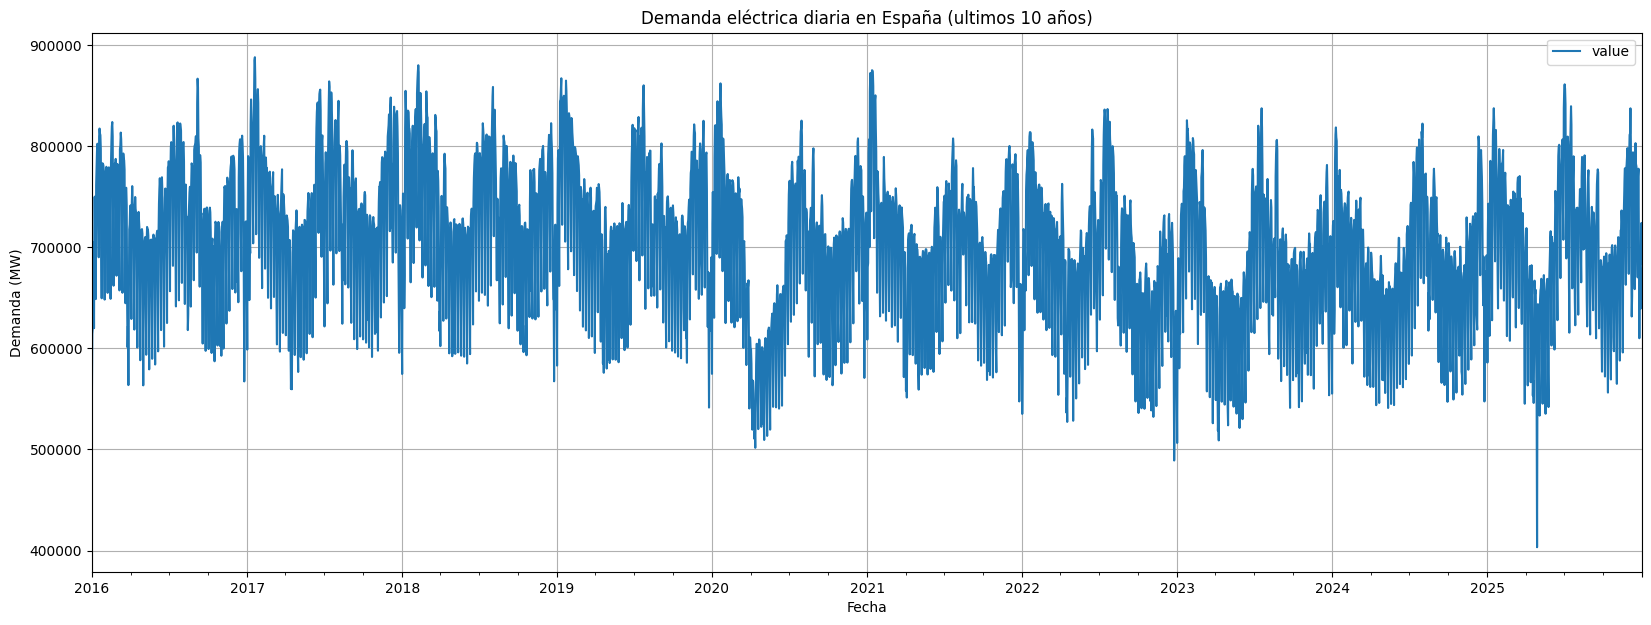

In [10]:
df_demanda.plot(
    x = "datetime_spain",
    y = "value",
    figsize=(20,7),
    title = "Demanda eléctrica diaria en España (ultimos 10 años)",
    xlabel = "Fecha",
    ylabel = "Demanda (MW)"
)

plt.grid(True)
plt.show()

In [11]:
df_demanda.to_csv("demanda_espania_10_anios.csv", index=False)

In [26]:
url = "https://apidatos.ree.es/es/datos/generacion/estructura-generacion"

params = {
    "start_date": "2014-01-01T00:00",
    "end_date": "2018-12-31T23:59",
    "time_trunc": "year",
    "geo_trunc": "electric_system",
    "geo_limit": "ccaa",
    "geo_ids": "7"
    
}

response = requests.get(url, params=params)

print(response.status_code)
print(response.url)
print(response.text[:1000])


200
https://apidatos.ree.es/es/datos/generacion/estructura-generacion?start_date=2014-01-01T00%3A00&end_date=2018-12-31T23%3A59&time_trunc=year&geo_trunc=electric_system&geo_limit=ccaa&geo_ids=7
{"data":{"type":"Generaci\u00f3n por tecnolog\u00eda","id":"gen1","attributes":{"title":"Generaci\u00f3n por tecnolog\u00eda","last-update":"2019-06-12T17:00:43.000+02:00","description":null},"meta":{"cache-control":{"cache":"HIT","expireAt":"2026-06-12T10:03:42"}}},"included":[{"type":"Hidr\u00e1ulica","id":"10330","groupId":"1","attributes":{"title":"Hidr\u00e1ulica","description":null,"color":"#0090d1","icon":null,"type":"Renovable","magnitude":null,"composite":false,"last-update":"2019-06-20T14:17:29.000+02:00","values":[{"value":1006208.552,"percentage":0.04482814638697235,"datetime":"2014-01-01T00:00:00.000+01:00"},{"value":700914.375,"percentage":0.03251746074817508,"datetime":"2015-01-01T00:00:00.000+01:00"},{"value":731944.331,"percentage":0.03446238183064846,"datetime":"2016-01-01T00:

In [28]:
data = response.json()

rows = []
for item in data["included"]:
    title = item["attributes"]["title"]
    values = item["attributes"].get("values", [])
    
    for v in values:
        rows.append({
            "region": "Castilla-La Mancha",
            "concept": title,
            "datetime": v["datetime"],
            "value": v["value"],
            "percentage": v.get("percentage")
        })

df_ccaa = pd.DataFrame(rows)

df_ccaa["datetime"] = pd.to_datetime(df_ccaa["datetime"], utc=True)

df_ccaa.head()

,region,concept,datetime,value,percentage
0,Castilla-La Mancha,Hidráulica,2013-12-31 23:00:00+00:00,1006208.552,0.044828
1,Castilla-La Mancha,Hidráulica,2014-12-31 23:00:00+00:00,700914.375,0.032517
2,Castilla-La Mancha,Hidráulica,2015-12-31 23:00:00+00:00,731944.331,0.034462
3,Castilla-La Mancha,Hidráulica,2016-12-31 23:00:00+00:00,410077.844,0.019174
4,Castilla-La Mancha,Hidráulica,2017-12-31 23:00:00+00:00,768189.817,0.035506


In [32]:
ccaa_ids = {
    "Andalucía": 4,
    "Aragón": 5,
    "Asturias": 11,
    "Cantabria": 12,
    "Castilla y León": 6,
    "Castilla-La Mancha": 7,
    "Cataluña": 9,
    "Comunidad Valenciana": 15,
    "Extremadura": 16,
    "Galicia": 17,
    "Madrid": 13,
    "Murcia": 14,
    "Navarra": 10,
    "País Vasco": 20,
    "La Rioja": 8,
    "Baleares": 8743,
    "Canarias": 8742
}

In [ ]:
url = "https://apidatos.ree.es/es/datos/demanda/evolucion"

params = {
    "start_date": "2014-01-01T00:00",
    "end_date": "2018-12-31T23:59",
    "time_trunc": "year",
    "geo_trunc": "electric_system",
    "geo_limit": "ccaa",
    "geo_ids": "7" #Castilla La Mancha
    
}

response = requests.get(url, params=params)

print(response.status_code)
print(response.url)
print(response.text[:1000])

200
https://apidatos.ree.es/es/datos/demanda/evolucion?start_date=2014-01-01T00%3A00&end_date=2018-12-31T23%3A59&time_trunc=year&geo_trunc=electric_system&geo_limit=ccaa&geo_ids=7
{"data":{"type":"Evoluci\u00f3n de la demanda","id":"dem1","attributes":{"title":"Evoluci\u00f3n de la demanda","last-update":"2019-06-12T17:00:44.000+02:00","description":null},"meta":{"cache-control":{"cache":"MISS"}}},"included":[{"type":"Demanda","id":"10339","groupId":null,"attributes":{"title":"Demanda","description":null,"color":"#ffea00","icon":null,"type":null,"magnitude":null,"composite":false,"last-update":"2020-04-23T13:07:28.000+02:00","values":[{"value":11606062.864,"percentage":1,"datetime":"2014-01-01T00:00:00.000+01:00"},{"value":11542102.873,"percentage":1,"datetime":"2015-01-01T00:00:00.000+01:00"},{"value":11685668.294,"percentage":1,"datetime":"2016-01-01T00:00:00.000+01:00"},{"value":11712859.761,"percentage":1,"datetime":"2017-01-01T00:00:00.000+01:00"},{"value":11966494.576,"percentage

In [31]:
data = response.json()

rows = []
for item in data["included"]:
    title = item["attributes"]["title"]
    values = item["attributes"].get("values", [])
    
    for v in values:
        rows.append({
            "region": "Castilla-La Mancha",
            "concept": title,
            "datetime": v["datetime"],
            "value": v["value"]
        })

df_ccaa = pd.DataFrame(rows)

df_ccaa["datetime"] = pd.to_datetime(df_ccaa["datetime"], utc=True)

df_ccaa.head()

,region,concept,datetime,value
0,Castilla-La Mancha,Demanda,2013-12-31 23:00:00+00:00,1.160606e+07
1,Castilla-La Mancha,Demanda,2014-12-31 23:00:00+00:00,1.154210e+07
2,Castilla-La Mancha,Demanda,2015-12-31 23:00:00+00:00,1.168567e+07
3,Castilla-La Mancha,Demanda,2016-12-31 23:00:00+00:00,1.171286e+07
4,Castilla-La Mancha,Demanda,2017-12-31 23:00:00+00:00,1.196649e+07


In [33]:
ccaa_ids = {
    "Andalucía": 4,
    "Aragón": 5,
    "Asturias": 11,
    "Cantabria": 12,
    "Castilla y León": 6,
    "Castilla-La Mancha": 7,
    "Cataluña": 9,
    "Comunidad Valenciana": 15,
    "Extremadura": 16,
    "Galicia": 17,
    "Madrid": 13,
    "Murcia": 14,
    "Navarra": 10,
    "País Vasco": 20,
    "La Rioja": 8,
    "Baleares": 8743,
    "Canarias": 8742
}